# 3 · Evaluation results

Reproduce the four experiments behind the README figures on a synthetic camera with known ground truth.

In [1]:
import os
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(ROOT)
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np, cv2

In [2]:
from campose import evaluation as ev
from campose.board import CheckerboardSpec
from campose.calibrator import CameraCalibrator
from campose.camera_model import CameraIntrinsics
from campose.synthetic import VirtualCamera, render_aruco_marker
from campose.pose_estimator import PoseEstimator, _marker_object_points

SPEC = CheckerboardSpec(9, 6, 0.025)
K = np.array([[920.,0,328],[0,918.,244],[0,0,1]])
DIST = np.array([-0.262,0.121,0.0009,-0.0007,0.018])
SIZE = (640, 480)
intr = CameraIntrinsics.from_matrix(K, DIST)

## Experiment 1 — calibration error vs image count

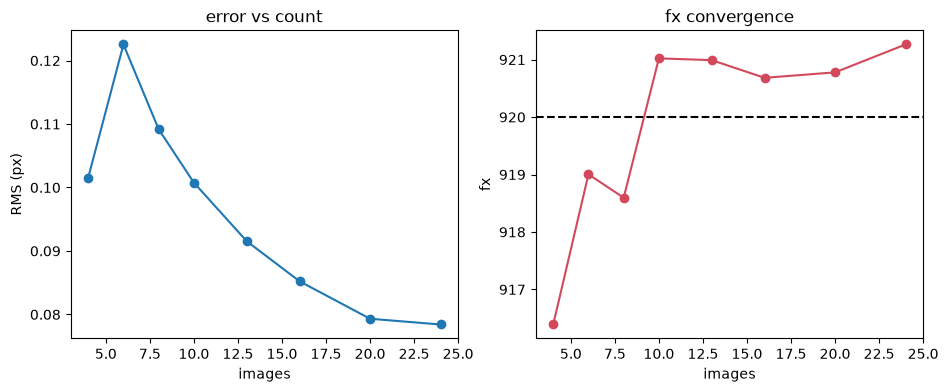

In [3]:
cam = VirtualCamera(intr, SIZE, SPEC)
rng = np.random.default_rng(7)
calib = CameraCalibrator(SPEC)
cx = -(SPEC.columns-1)*0.025/2; cy = -(SPEC.rows-1)*0.025/2
tries = 0
while calib.view_count < 24 and tries < 1500:
    tries += 1
    rvec = rng.uniform(-0.55,0.55,3)
    tvec = np.array([cx+rng.uniform(-0.05,0.05), cy+rng.uniform(-0.04,0.04), rng.uniform(0.55,1.05)])
    rb = cam.render(rvec, tvec)
    if rb.visible:
        calib.add_image(rb.image, source=f'v{calib.view_count:02d}')

counts = ev.calibration_vs_count(calib, [4,6,8,10,13,16,20,24])
fig, (a,b) = plt.subplots(1,2,figsize=(11,4))
a.plot([t.image_count for t in counts],[t.overall_rms for t in counts],'o-')
a.set_xlabel('images'); a.set_ylabel('RMS (px)'); a.set_title('error vs count')
b.plot([t.image_count for t in counts],[t.fx for t in counts],'o-',color='#d1495b')
b.axhline(K[0,0],ls='--',color='k'); b.set_xlabel('images'); b.set_ylabel('fx'); b.set_title('fx convergence')
plt.show()

## Experiment 2 — pose accuracy vs distance

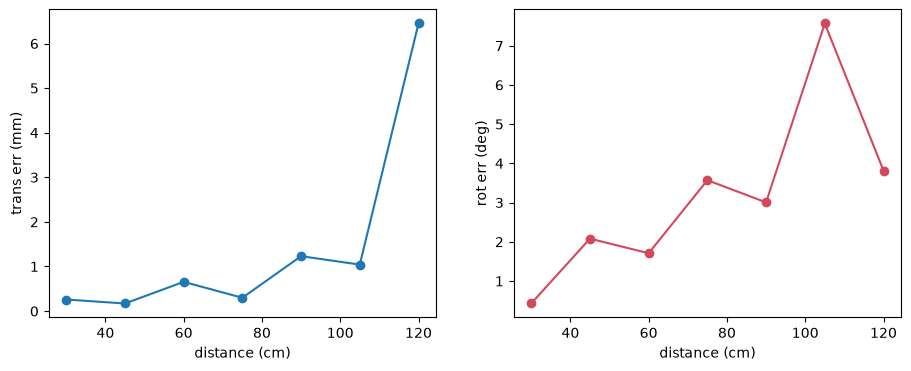

In [4]:
markers = [render_aruco_marker(intr, SIZE, 17, 0.08,
           np.array([0.06,-0.05,0.03]), np.array([0.0,0.0,d]))
           for d in [0.3,0.45,0.6,0.75,0.9,1.05,1.2]]
dist = ev.pose_vs_distance(markers, intr, 0.08)
fig, (a,b) = plt.subplots(1,2,figsize=(11,4))
a.plot([t.true_distance*100 for t in dist],[t.translation_error*1000 for t in dist],'o-')
a.set_xlabel('distance (cm)'); a.set_ylabel('trans err (mm)')
b.plot([t.true_distance*100 for t in dist],[t.rotation_error for t in dist],'o-',color='#d1495b')
b.set_xlabel('distance (cm)'); b.set_ylabel('rot err (deg)')
plt.show()

## Experiment 3 — PnP solver comparison

In [5]:
rendered = render_aruco_marker(intr, SIZE, 17, 0.08,
                               np.array([0.12,-0.16,0.05]), np.array([0.0,0.0,0.5]))
detected = PoseEstimator(intr).estimate_aruco(rendered.image, 0.08)[0]
trials = ev.solver_comparison(_marker_object_points(0.08), detected.image_points,
                              intr, rendered.rvec, rendered.tvec)
print(f"{'solver':>13} {'t_err(mm)':>10} {'r_err(deg)':>11} {'reproj(px)':>11} {'time(ms)':>9}")
for t in trials:
    print(f'{t.solver:>13} {t.translation_error*1000:10.2f} {t.rotation_error:11.2f} {t.reprojection_rms:11.3f} {t.solve_time_ms:9.3f}')

       solver  t_err(mm)  r_err(deg)  reproj(px)  time(ms)
         ippe       0.67        0.89       0.254     0.053
  ippe_square       0.67        0.89       0.254     0.026
         epnp       0.69        0.30       0.219     0.504
        sqpnp       0.69        0.30       0.219     0.263
         ap3p       0.69        0.30       0.219     0.154
          p3p       0.69        0.30       0.219     0.175
    iterative       0.69        0.30       0.219     0.264


## Experiment 4 — robustness stress test

In [6]:
degs = [('blur',3,ev.blur(3)),('blur',9,ev.blur(9)),('blur',15,ev.blur(15)),('blur',25,ev.blur(25)),
        ('occlude',0.1,ev.occlude(0.1)),('occlude',0.25,ev.occlude(0.25)),('occlude',0.5,ev.occlude(0.5)),
        ('dark',0.3,ev.darken(0.3)),('dark',0.1,ev.darken(0.1))]
for t in ev.robustness_sweep(rendered.image, intr, 0.08, degs):
    drift = '-' if t.translation_error is None else f'{t.translation_error*1000:.2f} mm'
    print(f'{t.condition:>8} {str(t.level):>5}  detected={t.detected!s:>5}  drift={drift}')

    blur     3  detected= True  drift=0.49 mm
    blur     9  detected= True  drift=1.98 mm
    blur    15  detected= True  drift=3.56 mm
    blur    25  detected= True  drift=6.18 mm
 occlude   0.1  detected= True  drift=0.00 mm
 occlude  0.25  detected= True  drift=0.00 mm
 occlude   0.5  detected=False  drift=-
    dark   0.3  detected= True  drift=0.02 mm
    dark   0.1  detected= True  drift=0.04 mm
